
# Практика 04. LSTM

Посмотрим на данные

## Гистограмма распределения по классам

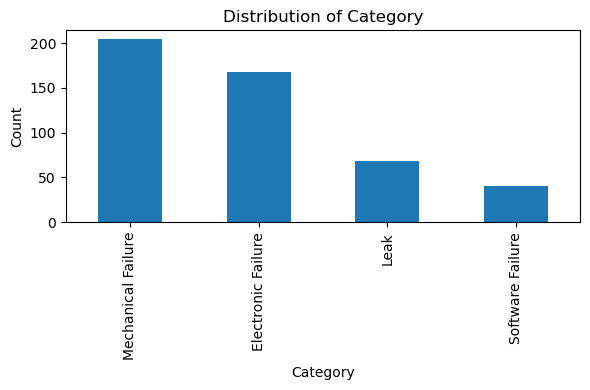

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter

df = pd.read_csv("factoryReports.csv")

col = "Category"  # в этом файле так и называется столбец класса
counts = df[col].value_counts()

plt.figure(figsize=(6, 4))
counts.plot(kind="bar")
plt.xlabel(col)
plt.ylabel("Count")
plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

На гистограмме четыре основных класса: Mechanical Failure, Electronic Failure, Leak и Software Failure, с заметным перевесом механических и электронных отказов.

## Облако слов (упрощённый вариант)

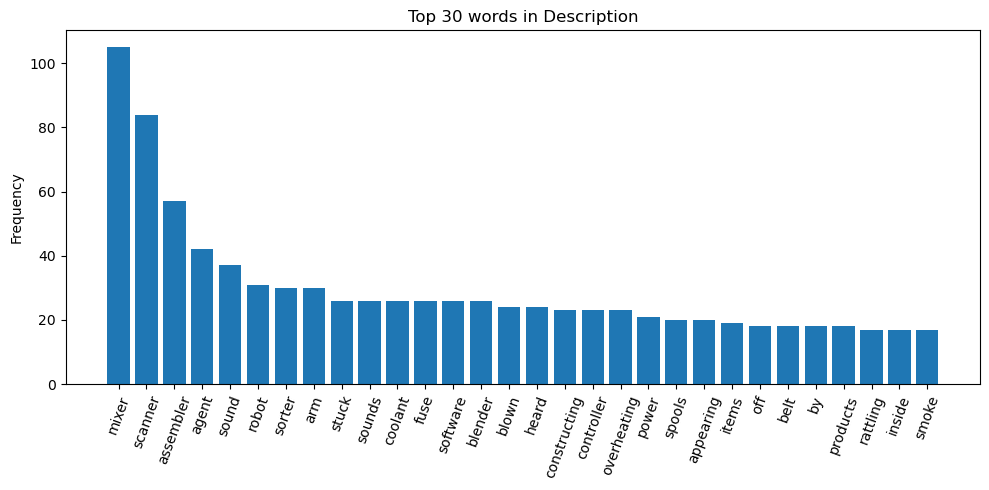

In [2]:
df = pd.read_csv("factoryReports.csv")
texts = df["Description"].astype(str).tolist()

def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return text.split()

counter = Counter()
for t in texts:
    counter.update(tokenize(t))

# простый список стоп-слов
stop_words = {
    "the","a","of","to","in","is","are","and","from","on","at",
    "for","will","some","be","when","you","while","there","then"
}
for w in stop_words:
    counter.pop(w, None)

most_common = counter.most_common(30)
words, freqs = zip(*most_common)

plt.figure(figsize=(10, 5))
plt.bar(range(len(words)), freqs)
plt.xticks(range(len(words)), words, rotation=70)
plt.ylabel("Frequency")
plt.title("Top 30 words in Description")
plt.tight_layout()
plt.show()

## Классическое облако слов

In [4]:
!pip install wordcloud

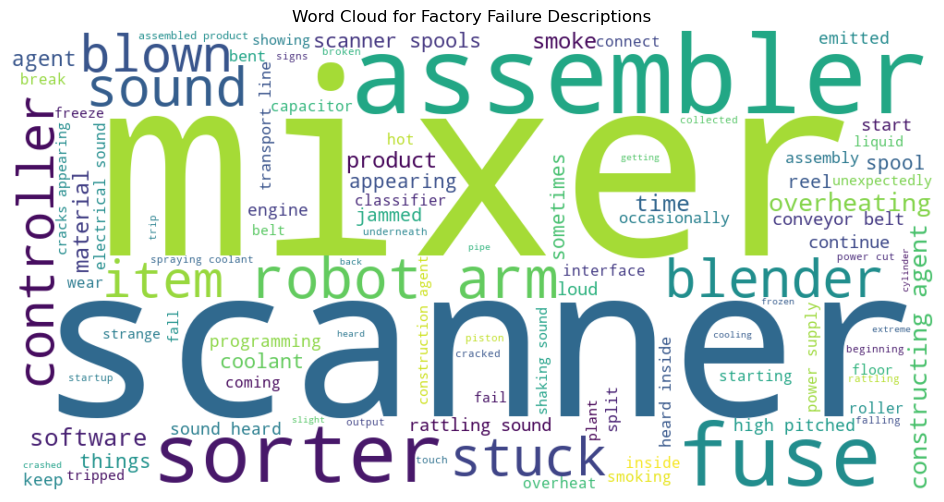

In [5]:
from wordcloud import WordCloud, STOPWORDS

# Загрузка данных
df = pd.read_csv("factoryReports.csv")

# Берём все описания
texts = df["Description"].astype(str).tolist()
full_text = " ".join(texts)

# Базовая очистка текста
def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return text

full_text = preprocess(full_text)

# Стоп-слова: стандартные + свои доменные
stopwords = set(STOPWORDS)
stopwords.update([
    "the", "a", "of", "to", "in", "is", "are", "from", "on", "at", "for",
    "will", "some", "be", "when", "you", "while", "there", "then"
])

# Генерация облака
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    stopwords=stopwords,
    max_words=100
).generate(full_text)

# Визуализация
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for Factory Failure Descriptions")
plt.show()

## Базовая модель

### Подготовка данных

In [20]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch import nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Загрузка данных
df = pd.read_csv("factoryReports.csv")

# Оставим только нужные столбцы
texts = df["Description"].astype(str).values
labels = df["Category"].astype(str).values

# 2. Кодирование меток
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)          # целые метки
num_classes = len(label_encoder.classes_)

# 3. Токенизация (очень простая: split по пробелам + нижний регистр)
def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    tokens = text.split()
    return tokens

tokenized_texts = [tokenize(t) for t in texts]

# 4. Построение словаря
counter = Counter()
for toks in tokenized_texts:
    counter.update(toks)

# Зарезервируем индексы
PAD_IDX = 0
UNK_IDX = 1

vocab = {"<pad>": PAD_IDX, "<unk>": UNK_IDX}
for word, _ in counter.most_common():   # можно ограничить размер, но тут оставим все
    if word not in vocab:
        vocab[word] = len(vocab)

vocab_size = len(vocab)

def numericalize(tokens):
    return [vocab.get(t, UNK_IDX) for t in tokens]

numericalized = [numericalize(toks) for toks in tokenized_texts]

# 5. Усечение/дополнение до фиксированной длины последовательности
MAX_LEN = 30

def pad_seq(seq, max_len=MAX_LEN):
    if len(seq) < max_len:
        return seq + [PAD_IDX] * (max_len - len(seq))
    else:
        return seq[:max_len]

X = [pad_seq(seq) for seq in numericalized]
X = torch.tensor(X, dtype=torch.long)
y = torch.tensor(y, dtype=torch.long)

# 6. Train/val split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Dataset и DataLoader

In [21]:
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 32

train_dataset = TextDataset(X_train, y_train)
val_dataset   = TextDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

### Базовая LSTM‑модель

In [22]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes,
                 pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,   # (batch, seq, feat)
            bidirectional=False # чисто базовая модель
        )
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # x: (batch, seq_len)
        emb = self.embedding(x)              # (batch, seq_len, embed_dim)
        out, (h_n, c_n) = self.lstm(emb)     # h_n: (num_layers, batch, hidden_dim)
        last_hidden = h_n[-1]                # (batch, hidden_dim)
        logits = self.fc(last_hidden)        # (batch, num_classes)
        return logits

embed_dim = 100
hidden_dim = 128

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMClassifier(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    hidden_dim=hidden_dim,
    num_classes=num_classes,
    pad_idx=PAD_IDX
).to(device)

### Обучение базовой модели

In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    return total_loss / total, correct / total

def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item() * X_batch.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    return total_loss / total, correct / total

num_epochs = 10

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc     = eval_epoch(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch:02d} | "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.3f} | "
          f"val_loss={val_loss:.4f}, val_acc={val_acc:.3f}")

Epoch 01 | train_loss=1.3575, train_acc=0.380 | val_loss=1.2990, val_acc=0.427
Epoch 02 | train_loss=1.2446, train_acc=0.424 | val_loss=1.2025, val_acc=0.427
Epoch 03 | train_loss=1.2245, train_acc=0.424 | val_loss=1.1914, val_acc=0.427
Epoch 04 | train_loss=1.1967, train_acc=0.424 | val_loss=1.1639, val_acc=0.427
Epoch 05 | train_loss=1.1050, train_acc=0.424 | val_loss=1.0084, val_acc=0.427
Epoch 06 | train_loss=0.9741, train_acc=0.388 | val_loss=0.9773, val_acc=0.510
Epoch 07 | train_loss=0.9194, train_acc=0.542 | val_loss=1.0626, val_acc=0.490
Epoch 08 | train_loss=0.9660, train_acc=0.474 | val_loss=1.1937, val_acc=0.458
Epoch 09 | train_loss=0.9670, train_acc=0.500 | val_loss=1.0763, val_acc=0.469
Epoch 10 | train_loss=0.9008, train_acc=0.419 | val_loss=1.0428, val_acc=0.490


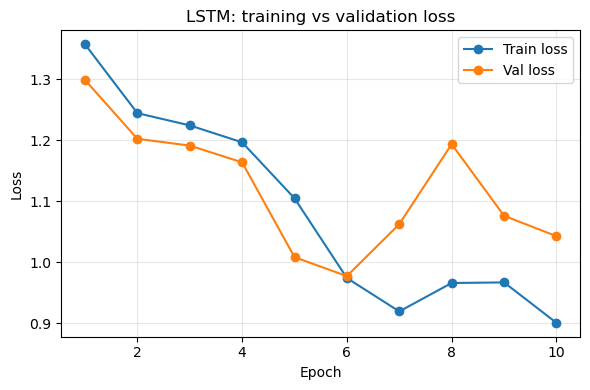

In [24]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, train_losses, marker="o", label="Train loss")
plt.plot(epochs, val_losses, marker="o", label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM: training vs validation loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

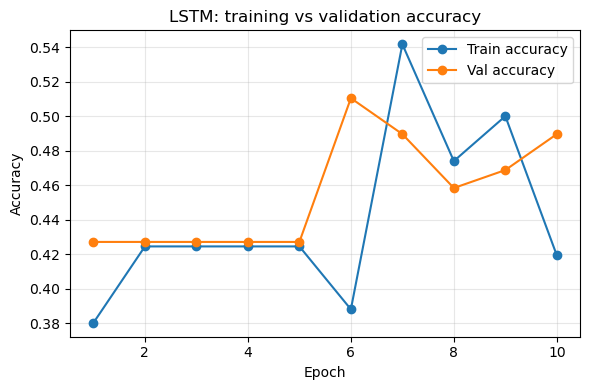

In [25]:
plt.figure(figsize=(6, 4))
plt.plot(epochs, train_accs, marker="o", label="Train accuracy")
plt.plot(epochs, val_accs, marker="o", label="Val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM: training vs validation accuracy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Пример инференса для новой заявки

In [26]:
def predict_category(model, text):
    model.eval()
    tokens = tokenize(text)
    ids = pad_seq(numericalize(tokens))
    inp = torch.tensor([ids], dtype=torch.long).to(device)
    with torch.no_grad():
        logits = model(inp)
        pred = logits.argmax(dim=1).item()
    return label_encoder.inverse_transform([pred])[0]

example = "Mixer is making a strange high pitched noise."
print(predict_category(model, example))

Mechanical Failure


In [27]:
example2 = "Ghb dsflkgjh lkjsajg adslkjfg."
print(predict_category(model, example2))

Mechanical Failure


In [28]:
example3 = "."
print(predict_category(model, example3))

Leak


In [29]:
example4 = "Strange electrical sounds from the scanner"
print(predict_category(model, example4)) # А вот и ошибочка...

Mechanical Failure


In [30]:
example5 = "Mixing software has crashed"
print(predict_category(model, example5)) # А вот и ошибочка 2...

Leak


## Более сложная модель (risk of overfit)

Заменяем базовый класс на более тяжёлый:

In [31]:
class BigLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers,
                 num_classes, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True   # увеличиваем размер в 2 раза
        )
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        emb = self.embedding(x)
        out, (h_n, c_n) = self.lstm(emb)
        # берём последний hidden из обоих направлений
        last_hidden = torch.cat((h_n[-2], h_n[-1]), dim=1)
        logits = self.fc(last_hidden)
        return logits

# параметры заведомо «тяжелее» базовых
embed_dim = 200
hidden_dim = 256
num_layers = 2

big_model = BigLSTMClassifier(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    num_classes=num_classes,
    pad_idx=PAD_IDX
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(big_model.parameters(), lr=1e-3)

Обучаем много эпох и логируем кривые

In [32]:
num_epochs = 40  # сильно больше, чем в базовом эксперименте

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_epoch(big_model, train_loader, optimizer, criterion, device)
    val_loss, val_acc     = eval_epoch(big_model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch:02d} | "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.3f} | "
          f"val_loss={val_loss:.4f}, val_acc={val_acc:.3f}")

Epoch 01 | train_loss=1.1598, train_acc=0.490 | val_loss=0.8555, val_acc=0.719
Epoch 02 | train_loss=0.5430, train_acc=0.826 | val_loss=0.3389, val_acc=0.885
Epoch 03 | train_loss=0.1804, train_acc=0.951 | val_loss=0.2505, val_acc=0.917
Epoch 04 | train_loss=0.0623, train_acc=0.987 | val_loss=0.2733, val_acc=0.885
Epoch 05 | train_loss=0.0389, train_acc=0.990 | val_loss=0.2151, val_acc=0.938
Epoch 06 | train_loss=0.0224, train_acc=0.995 | val_loss=0.2353, val_acc=0.948
Epoch 07 | train_loss=0.0161, train_acc=0.995 | val_loss=0.2154, val_acc=0.938
Epoch 08 | train_loss=0.0188, train_acc=0.990 | val_loss=0.2285, val_acc=0.948
Epoch 09 | train_loss=0.0176, train_acc=0.992 | val_loss=0.2971, val_acc=0.906
Epoch 10 | train_loss=0.0137, train_acc=0.995 | val_loss=0.2848, val_acc=0.917
Epoch 11 | train_loss=0.0143, train_acc=0.995 | val_loss=0.2811, val_acc=0.938
Epoch 12 | train_loss=0.0140, train_acc=0.992 | val_loss=0.2821, val_acc=0.927
Epoch 13 | train_loss=0.0184, train_acc=0.995 | val_

Визуализация переобучения

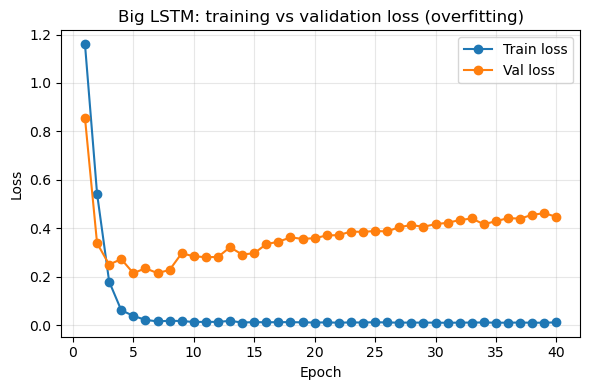

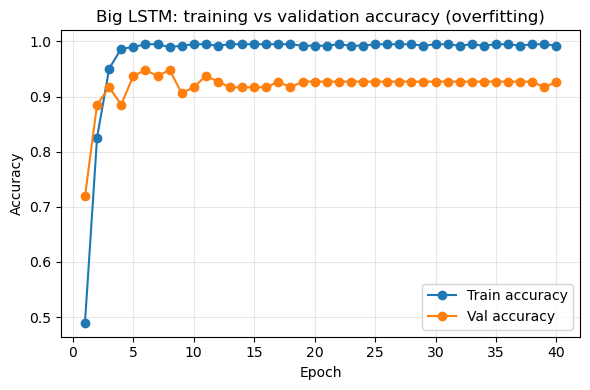

In [33]:
epochs = range(1, len(train_losses) + 1)

# Loss
plt.figure(figsize=(6, 4))
plt.plot(epochs, train_losses, marker="o", label="Train loss")
plt.plot(epochs, val_losses, marker="o", label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Big LSTM: training vs validation loss (overfitting)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Accuracy
plt.figure(figsize=(6, 4))
plt.plot(epochs, train_accs, marker="o", label="Train accuracy")
plt.plot(epochs, val_accs, marker="o", label="Val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Big LSTM: training vs validation accuracy (overfitting)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## "Хорошая" модель

1. Оптимизация длины и словаря/

Посчитаем реальные длины и обрежем словарь по частоте (например, оставить топ‑500–1000 слов, остальные → "unk").

In [34]:
df = pd.read_csv("factoryReports.csv")
texts = df["Description"].astype(str).tolist()

def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return text.split()

tokenized_texts = [tokenize(t) for t in texts]
lengths = [len(toks) for toks in tokenized_texts]
print("min/avg/max len:", min(lengths), sum(lengths)/len(lengths), max(lengths))

# допустим, по статистике max_len ~= 15, возьмём небольшой запас
MAX_LEN = 16

# строим словарь, ограничивая по частоте
counter = Counter()
for toks in tokenized_texts:
    counter.update(toks)

PAD_IDX = 0
UNK_IDX = 1
vocab = {"<pad>": PAD_IDX, "<unk>": UNK_IDX}

max_vocab_size = 800          # для коротких текстов достаточно
min_freq = 2                  # единичные слова в unk

for word, freq in counter.most_common():
    if freq < min_freq:
        continue
    if len(vocab) >= max_vocab_size:
        break
    vocab[word] = len(vocab)

vocab_size = len(vocab)
print("vocab_size:", vocab_size)

min/avg/max len: 3 6.16875 15
vocab_size: 295


Далее — числовое представление с новой MAX_LEN и обновлённым словарём.

In [35]:
def numericalize(tokens):
    return [vocab.get(t, UNK_IDX) for t in tokens]

numericalized = [numericalize(toks) for toks in tokenized_texts]

def pad_seq(seq, max_len=MAX_LEN):
    if len(seq) < max_len:
        return seq + [PAD_IDX] * (max_len - len(seq))
    else:
        return seq[:max_len]

X = torch.tensor([pad_seq(seq) for seq in numericalized], dtype=torch.long)

Дальше — тот же LabelEncoder, train_test_split и DataLoader, только переиспользуем новые X.

In [37]:
labels = df["Category"].astype(str).values
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)
y = torch.tensor(y, dtype=torch.long)

num_classes = len(label_encoder.classes_)

In [38]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [39]:
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TextDataset(X_train, y_train)
val_dataset   = TextDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

### Модель с дропаутом и L2‑регуляризацией
Используем dropout внутри nn.LSTM (работает при num_layers > 1) и отдельный nn.Dropout перед выходным слоем. L2‑регуляризацию задаём через weight_decay в оптимизаторе.

In [42]:
class RegularizedLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers,
                 num_classes, pad_idx=0, dropout_p=0.5, bidirectional=True):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim
        self.bidirectional = bidirectional

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout_p if num_layers > 1 else 0.0  # встроенный dropout
        )

        self.dropout = nn.Dropout(dropout_p)  # dropout перед классификатором

        fc_in_dim = hidden_dim * (2 if bidirectional else 1)
        self.fc = nn.Linear(fc_in_dim, num_classes)

    def forward(self, x):
        emb = self.embedding(x)                     # (B, T, E)
        out, (h_n, c_n) = self.lstm(emb)
        if self.bidirectional:
            last_hidden = torch.cat((h_n[-2], h_n[-1]), dim=1)
        else:
            last_hidden = h_n[-1]
        last_hidden = self.dropout(last_hidden)     # droupout только на train
        logits = self.fc(last_hidden)
        return logits

embed_dim = 100
hidden_dim = 128
num_layers = 2
dropout_p = 0.5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = RegularizedLSTMClassifier(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    num_classes=num_classes,
    pad_idx=PAD_IDX,
    dropout_p=dropout_p,
    bidirectional=True
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4   # L2‑регуляризация
)

Обучение

In [43]:
num_epochs = 10

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_epoch(big_model, train_loader, optimizer, criterion, device)
    val_loss, val_acc     = eval_epoch(big_model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch:02d} | "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.3f} | "
          f"val_loss={val_loss:.4f}, val_acc={val_acc:.3f}")

Epoch 01 | train_loss=0.0550, train_acc=0.984 | val_loss=0.5055, val_acc=0.906
Epoch 02 | train_loss=0.0550, train_acc=0.984 | val_loss=0.5055, val_acc=0.906
Epoch 03 | train_loss=0.0550, train_acc=0.984 | val_loss=0.5055, val_acc=0.906
Epoch 04 | train_loss=0.0550, train_acc=0.984 | val_loss=0.5055, val_acc=0.906
Epoch 05 | train_loss=0.0550, train_acc=0.984 | val_loss=0.5055, val_acc=0.906
Epoch 06 | train_loss=0.0550, train_acc=0.984 | val_loss=0.5055, val_acc=0.906
Epoch 07 | train_loss=0.0550, train_acc=0.984 | val_loss=0.5055, val_acc=0.906
Epoch 08 | train_loss=0.0550, train_acc=0.984 | val_loss=0.5055, val_acc=0.906
Epoch 09 | train_loss=0.0550, train_acc=0.984 | val_loss=0.5055, val_acc=0.906
Epoch 10 | train_loss=0.0550, train_acc=0.984 | val_loss=0.5055, val_acc=0.906


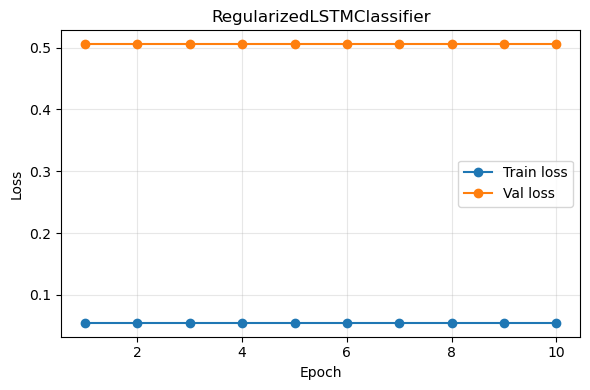

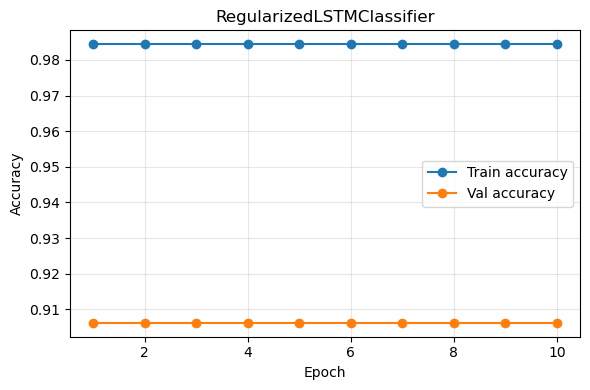

In [45]:
epochs = range(1, len(train_losses) + 1)

# Loss
plt.figure(figsize=(6, 4))
plt.plot(epochs, train_losses, marker="o", label="Train loss")
plt.plot(epochs, val_losses, marker="o", label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RegularizedLSTMClassifier")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Accuracy
plt.figure(figsize=(6, 4))
plt.plot(epochs, train_accs, marker="o", label="Train accuracy")
plt.plot(epochs, val_accs, marker="o", label="Val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("RegularizedLSTMClassifier")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [46]:
example4 = "Strange electrical sounds from the scanner"
print(predict_category(model, example4)) # Сегодня не везет...

Leak


In [47]:
example5 = "Mixing software has crashed"
print(predict_category(model, example5)) # Не наш день...

Leak


# Практическое задание

1. Построить все-таки "хорошую" модель на использованном датасете.

2. Решить задачу классификации для датасета из прошлой практической работы при помощи LSTM. Можно устроить подбор гиперпараметров (диапазоны embed_dim, hidden_dim, dropout_p, weight_decay) для максимизации val-точности.